In [1]:
import pandas as pd
import numpy as np

expr = pd.read_csv(
    "../data/processed/expression_matrix.csv"
)

expr.iloc[:,1:] = np.log2(expr.iloc[:,1:] + 1)

variance = expr.iloc[:,1:].var(axis=1)

expr = expr.loc[variance > 0.1]

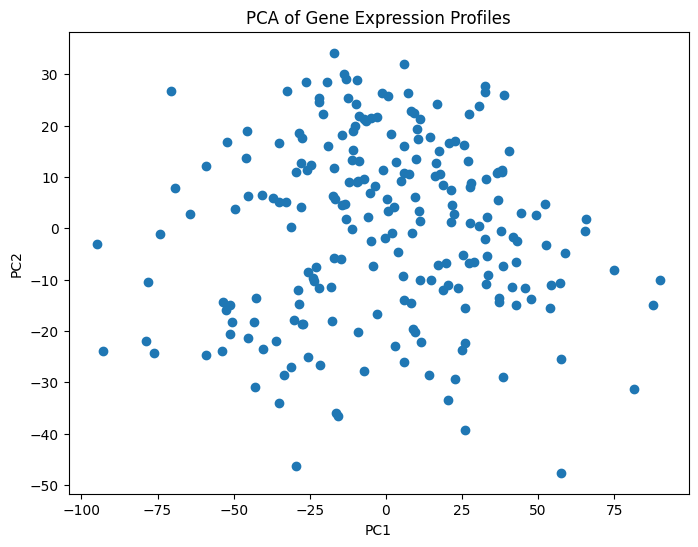

In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = expr.iloc[:,1:].T

pca = PCA(n_components=2)

components = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Gene Expression Profiles")

plt.savefig("../outputs/figures/pca_qc.png")
plt.show()

## Quality Control

Principal component analysis demonstrated clustering
patterns among transcriptomic profiles, suggesting
underlying biological variation between samples.